<img src='../data/LogoUPS.png' width="400">


Introduction to Timeseries

## Background

Recall that a timeseries $X(t)$ is an ordered data sequence, either continuous or discrete. On a computer, everything is discretized, so regardless of the original process, what we have is a discrete sequence $X_1, \cdots, X_n$, with each $X_i$ corresponding to times $t_i$ in $t_1, \cdots, t_n$.

In timeseries analysis, it is common to consider $X(t)$ as the sum of one or more oscillatory, stationary components (or ``signals''); a **trend** $q(t)$, and **noise** $\varepsilon_t$.  The oscillatory components are often the reason we're doing the analysis in the first place -- it will tell us how big they are and what their frequency is. 

Whether or not those oscillatory components are present, a **trend** is often present as well. 
In today's world the word "trend" is so overused that it has lost all meaning. Here, it will refer to a **slowly-evolving, non-stationary component that dominates the behavior of the timeseries**. For instance: a linear increase or decrease; a sinusoidal component so slow that its period is not resolved by the dataset; a nonlinear trend like the exponential increase of the Keeling curve (see below). 

As for **noise**, it clearly involves a subjective definition. Under this name we usually subsume any variable component in which we are not interested. Some of this noise may be composed of actual measurement errors (what you would think of as noise, strictly speaking), but some of it could be what another analyst would call "signal"". If you study climate, daily fluctuations are noise; if you study weather, they are your signal.  One commonly says that *one analyst's signal is another analyst's noise*.  This noise is often modeled as a Normal random process with zero mean, $\varepsilon \sim \mathcal{N}(0,\sigma^2)$ (aka "Gaussian white noise") .

**References:** Mudelsee M. Statistical Analysis of Climate Extremes https://www.cambridge.org/core/books/statistical-analysis-of-climate-extremes/8950D5D7306AE2BFC4EFB882CF5B33B6 


## 1. Create time series objects the classical way

In [1]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [5]:
## Read CO2 data from Mauna Loa
cols = ['Yr','Mn','XLDate','Date','CO2','seasonally adjusted','fit','seasonally adjusted fit','CO2 filled',	'seasonally adjusted filled','Sta']
df = pd.read_csv("../data/monthly_in_situ_co2_mlo.csv",header=64, names=cols) # read in the data
df.head() # display the top

,Yr,Mn,XLDate,Date,CO2,seasonally adjusted,fit,seasonally adjusted fit,CO2 filled,seasonally adjusted filled,Sta
0,1958,2,21231,1958.1260,-99.99,-99.99,-99.99,-99.99,-99.99,-99.99,MLO
1,1958,3,21259,1958.2027,315.71,314.43,316.20,314.90,315.71,314.43,MLO
2,1958,4,21290,1958.2877,317.45,315.15,317.30,314.98,317.45,315.15,MLO
3,1958,5,21320,1958.3699,317.51,314.68,317.89,315.06,317.51,314.68,MLO
4,1958,6,21351,1958.4548,-99.99,-99.99,317.27,315.14,317.27,315.14,MLO


By default, `pandas` indexed the rows by their number (starting at 0 as it's Python). Let's extract the actual dates, convert them to a usable format, and re-index the dataframe:

In [6]:
date = pd.to_datetime(df['XLDate'], unit='D', origin='1899-12-30') # convert from Excel's weird standard to something human-readable
date.name = None
df.index=date
df.head()

,Yr,Mn,XLDate,Date,CO2,seasonally adjusted,fit,seasonally adjusted fit,CO2 filled,seasonally adjusted filled,Sta
1958-02-15,1958,2,21231,1958.1260,-99.99,-99.99,-99.99,-99.99,-99.99,-99.99,MLO
1958-03-15,1958,3,21259,1958.2027,315.71,314.43,316.20,314.90,315.71,314.43,MLO
1958-04-15,1958,4,21290,1958.2877,317.45,315.15,317.30,314.98,317.45,315.15,MLO
1958-05-15,1958,5,21320,1958.3699,317.51,314.68,317.89,315.06,317.51,314.68,MLO
1958-06-15,1958,6,21351,1958.4548,-99.99,-99.99,317.27,315.14,317.27,315.14,MLO


Next, let's extract the column that we want to play with and make a new data frame out of it: 

In [7]:
co2 = df[['Date','CO2 filled']]
co2.rename(columns={'Date': 'Year', 'CO2 filled': 'CO2'},inplace=True) # rename columns for clarity
co2.head()

,Year,CO2
1958-02-15,1958.1260,-99.99
1958-03-15,1958.2027,315.71
1958-04-15,1958.2877,317.45
1958-05-15,1958.3699,317.51
1958-06-15,1958.4548,317.27


One last thing: the first and last value are missing, and they are encoded as -99, which is rather annoying (but unfortunately common; [NaN](https://en.wikipedia.org/wiki/NaN) would be a much less disruptive choice), so let's restrict our analysis to a safe, 66y interval:

In [8]:
co2 = co2.loc['1958-03-15':'2024-02-15']

Let's plot our time series object imported as pyleoclim

<Axes: title={'center': 'Mauna Loa Dataset (latest)'}, ylabel='CO2 [ppm]'>

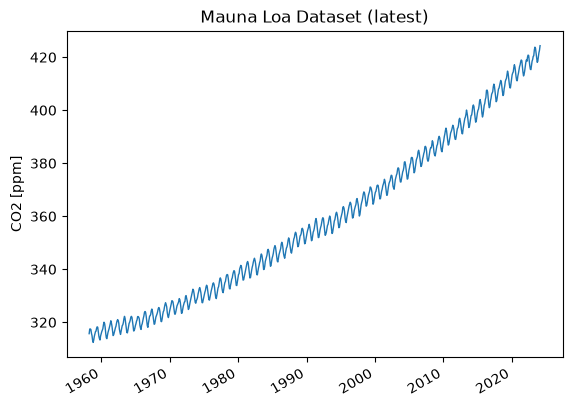

In [9]:
co2['CO2'].plot(linewidth=1,ylabel='CO2 [ppm]',title="Mauna Loa Dataset (latest)")

## 2. Using Pyleoclim

In [10]:
## Import libraries
import pyleoclim as pyleo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [16]:
## Izobamba data (gently provided by Dayana Gualotuña)

izobamba = pd.read_csv("../data/izobamba_2014_2025.csv", na_values=['', ' ', '   ', '     '], keep_default_na=True)
ts_izobamba = pyleo.Series(
    time=izobamba.iloc[:,2],
    value = izobamba.iloc[:,1],
    time_name = 'Years',
    time_unit = 'Años',
    value_name= 'Precipitation',
    label= 'mm',
    dropna=True
)

NaNs have been detected and dropped.
Time axis values sorted in ascending order


(<Figure size 1000x400 with 1 Axes>,
 <Axes: xlabel='Time [Años]', ylabel='Precipitation'>)

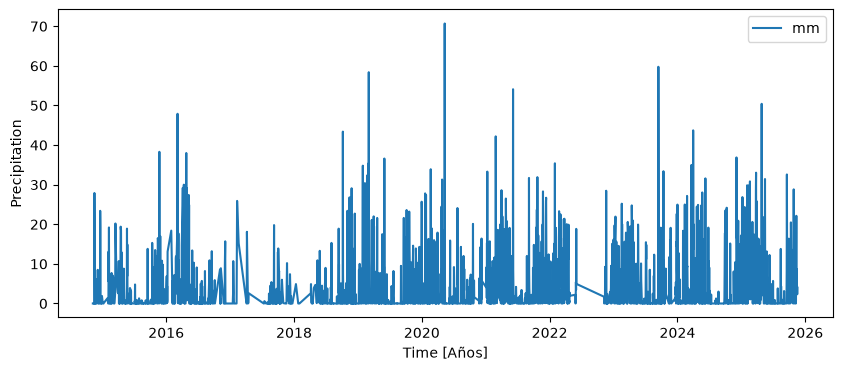

In [18]:
## Let's plot our data
ts_izobamba.plot()

Pyleoclim allows us to import different type of extensions (.xlsx, .csv, .txt, .dat, etc) and standardize into a single **pyleoSeries** object, here some examples using the different ENSO indexes. 

Here we import the "C" and "E" indexes from the seminal paper of Takahashi et al.2011 https://agupubs.onlinelibrary.wiley.com/doi/10.1029/2011GL047364 

In [20]:
## EC Indices Takahashi 2011 http://met.igp.gob.pe/elnino/indices.html
ectaka = pd.read_table(
    r'../data/Takahashi_EC_Indices.txt',
    sep=r'\s+',
    comment='%',
    header=None,
    engine='python'
)

# Assign correct column names
ectaka.columns = ["yy", "mm", "E", "C"]
ectaka["DecimalYear"] = ectaka["yy"] + (ectaka["mm"] - 0.5) / 12.0

## E-index
ts_etaka = pyleo.Series(
    time=ectaka.iloc[:, 4],   # DecimalYear
    value=ectaka.iloc[:, 2],  # E index
    time_name='Age',
    time_unit='Years',
    value_name='E index',
    label='E index',
    verbose=False,
    dropna=False
)

## C-index
ts_ctaka = pyleo.Series(
    time=ectaka.iloc[:, 4],   # DecimalYear
    value=ectaka.iloc[:, 3],  # E index
    time_name='Age',
    time_unit='Years',
    value_name='C index',
    label='C index',
    verbose=False,
    dropna=False
)

In addition, we can import from records from the Pyleoclim database

In [22]:
import pyleoclim as pyleo
pyleo.utils.available_dataset_names()

['SOI',
 'NINO3',
 'HadCRUT5',
 'AIR',
 'LR04',
 'AACO2',
 'EDC-dD',
 'GISP2',
 'cenogrid_d18O',
 'cenogrid_d13C']

To load the SOI, simply do:

In [23]:
SOI = pyleo.utils.load_dataset('SOI')
SOI

{'archiveType': 'Instrumental', 'label': 'Southern Oscillation Index'}


None
Time [year C.E.]
1866.002894   -0.62
1866.087769   -0.12
1866.164431   -0.62
1866.249306   -0.65
1866.331443    0.04
               ... 
2024.752349    0.35
2024.837224    0.61
2024.919362    1.09
2025.004237    0.26
2025.089112    0.21
Name: SOI [mb], Length: 1910, dtype: float64

(<Figure size 1000x400 with 1 Axes>,
 <Axes: xlabel='Time [year C.E.]', ylabel='SOI [mb]'>)

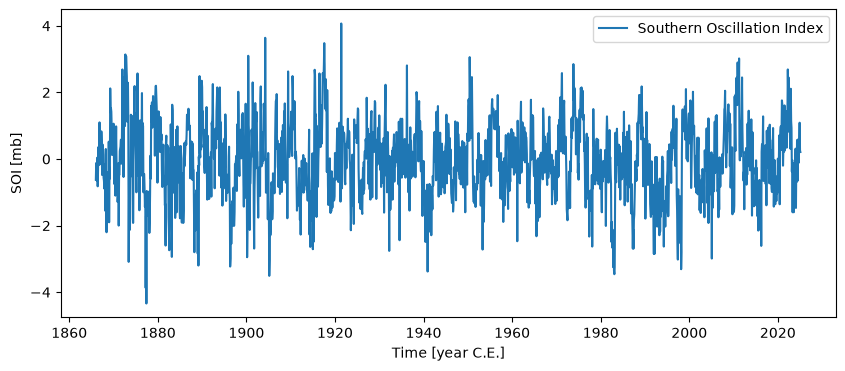

In [24]:
SOI.plot()

That was the easy part. For the NAO index, we have to work a little harder. Here you will see that pyleoclim series can also be created using a "metadata" information inserted into the pyleoclim routine

In [26]:
import pandas as pd
url = 'https://www.cpc.ncep.noaa.gov/products/precip/CWlink/pna/norm.nao.monthly.b5001.current.ascii.table'
df_nao = pd.read_csv(url, sep='\s+', header=0, index_col=0)
df_nao

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
1950,0.92,0.40,-0.36,0.73,-0.59,-0.06,-1.26,-0.05,0.25,0.85,-1.26,-1.02
1951,0.08,0.70,-1.02,-0.22,-0.59,-1.64,1.37,-0.22,-1.36,1.87,-0.39,1.32
1952,0.93,-0.83,-1.49,1.01,-1.12,-0.40,-0.09,-0.28,-0.54,-0.73,-1.13,-0.43
1953,0.33,-0.49,-0.04,-1.67,-0.66,1.09,0.40,-0.71,-0.35,1.32,1.04,-0.47
1954,0.37,0.74,-0.83,1.34,-0.09,-0.25,-0.60,-1.90,-0.44,0.60,0.40,0.69
...,...,...,...,...,...,...,...,...,...,...,...,...
2022,1.08,1.68,0.77,-0.36,0.71,-0.12,-0.09,1.47,-1.61,-0.72,0.69,-0.15
2023,1.25,0.92,-1.11,-0.63,0.39,-0.58,-2.17,-1.16,-0.44,-2.03,-0.32,1.94
2024,0.21,1.09,-0.21,-0.78,-0.44,-0.09,1.46,0.63,-1.43,-0.38,-0.23,1.21
2025,-0.52,1.60,0.30,0.18,0.49,0.70,0.48,0.26,-0.80,-0.96,-0.78,-0.65


Here we have a challenge: the data present themselves as a 2-dimensional table, and need to be reshaped into a 1-D series by somehow combining months and years in a sequential fashion. Fear not! `Pandas` can do!

First, we turn the index as a column called Year:

In [30]:
df_nao = df_nao.reset_index().rename(columns={'index':'Year'})
df_nao

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
0,1950,0.92,0.40,-0.36,0.73,-0.59,-0.06,-1.26,-0.05,0.25,0.85,-1.26,-1.02
1,1951,0.08,0.70,-1.02,-0.22,-0.59,-1.64,1.37,-0.22,-1.36,1.87,-0.39,1.32
2,1952,0.93,-0.83,-1.49,1.01,-1.12,-0.40,-0.09,-0.28,-0.54,-0.73,-1.13,-0.43
3,1953,0.33,-0.49,-0.04,-1.67,-0.66,1.09,0.40,-0.71,-0.35,1.32,1.04,-0.47
4,1954,0.37,0.74,-0.83,1.34,-0.09,-0.25,-0.60,-1.90,-0.44,0.60,0.40,0.69
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,2022,1.08,1.68,0.77,-0.36,0.71,-0.12,-0.09,1.47,-1.61,-0.72,0.69,-0.15
73,2023,1.25,0.92,-1.11,-0.63,0.39,-0.58,-2.17,-1.16,-0.44,-2.03,-0.32,1.94
74,2024,0.21,1.09,-0.21,-0.78,-0.44,-0.09,1.46,0.63,-1.43,-0.38,-0.23,1.21
75,2025,-0.52,1.60,0.30,0.18,0.49,0.70,0.48,0.26,-0.80,-0.96,-0.78,-0.65


Next, we invoke `pandas`' powerful [melt](https://pandas.pydata.org/docs/reference/api/pandas.melt.html) function to unpivot the table:

In [31]:
df_nao = df_nao.melt(id_vars='Year', var_name='Month', value_name='NAO')
df_nao

,Year,Month,NAO
0,1950,Jan,0.92
1,1951,Jan,0.08
2,1952,Jan,0.93
3,1953,Jan,0.33
4,1954,Jan,0.37
...,...,...,...
919,2022,Dec,-0.15
920,2023,Dec,1.94
921,2024,Dec,1.21
922,2025,Dec,-0.65


Next we combine year and month into a date, then ditch the superfluous year and month columns:

In [33]:
df_nao['date']=(df_nao
          .assign(Date=lambda x: pd.to_datetime(x['Year'].astype(str) + '-' + x['Month'], format='%Y-%b')))['Date']             
df_nao = df_nao.drop(columns=['Year', 'Month']).set_index('date').sort_index()
df_nao

,NAO
date,
1950-01-01,0.92
1950-02-01,0.40
1950-03-01,-0.36
1950-04-01,0.73
1950-05-01,-0.59
...,...
2026-08-01,-1.92
2026-09-01,NaN
2026-10-01,NaN


(<Figure size 1000x400 with 1 Axes>,
 <Axes: xlabel='Time [years CE]', ylabel='NAO'>)

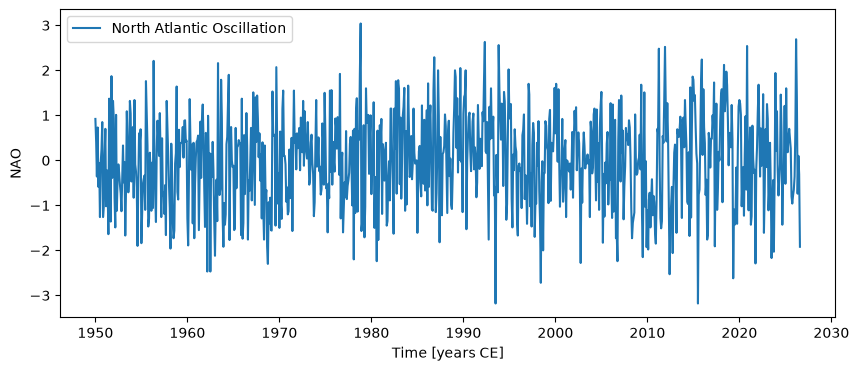

In [34]:
metadata = {
        'time_unit': 'years CE',
        'time_name': 'Time',
        'value_name': 'NAO',
        'label': 'North Atlantic Oscillation',
        'archiveType': 'Instrumental',
        'importedFrom': 'NOAA/NCEI',
    }

NAO = pyleo.Series.from_pandas(df_nao['NAO'],metadata)
NAO.plot()